In [7]:
import os
import sys

# Go to correct folder
%cd /content/datascience_projects/nationality_detection

# Add current directory to Python path
sys.path.append(os.getcwd())

print("Current path:", os.getcwd())
print("Files:", os.listdir())

/content/datascience_projects/nationality_detection
Current path: /content/datascience_projects/nationality_detection
Files: ['predictor.py', 'app.py', 'download (2).jpeg', 'README.md', 'requirements.txt', '.gitignore', 'config.py', 'logger.py', 'nationality_notebook.ipynb', 'download_models.py', 'cli.py', 'gui_components.py', 'test_predictor.py', 'models']


In [1]:
!pip install deepface opencv-python opencv-contrib-python pillow numpy matplotlib -q
print("✓ Installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.9 MB/s eta 0:00:00
✓ Installed


In [2]:
!git clone https://github.com/palak2564/datascience_projects.git
%cd datascience_projects/nationality_detection

Cloning into 'datascience_projects'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 162 (delta 42), reused 97 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 5.11 MiB | 17.51 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/datascience_projects/nationality_detection


In [3]:
import sys
sys.path.append(".")


In [5]:
from google.colab import files
uploaded = files.upload()

Saving download (2).jpeg to download (2).jpeg


26-03-25 06:31:16 - Directory /root/.deepface has been created
26-03-25 06:31:16 - Directory /root/.deepface/weights has been created



🔍 Processing: download (2).jpeg
26-03-25 06:31:23 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5
100%|██████████| 537M/537M [00:02<00:00, 234MB/s]


26-03-25 06:31:27 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 76.3MB/s]


26-03-25 06:31:29 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5
100%|██████████| 539M/539M [00:02<00:00, 269MB/s]


────────────────────────────────────────
Nationality  : American (100.0%)
Emotion      : Happy
Age          : 30
Face Found   : True
────────────────────────────────────────


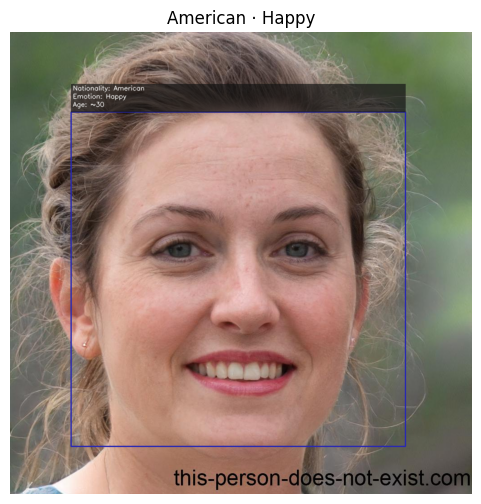

In [9]:
from predictor import NationalityPredictor
import cv2
import matplotlib.pyplot as plt
import os

predictor = NationalityPredictor()

os.makedirs("outputs", exist_ok=True)

for filename in uploaded.keys():

    print(f"\n🔍 Processing: {filename}")

    result = predictor.analyse(filename)

    # ---- Print results ----
    print("─"*40)
    print(f"Nationality  : {result['nationality']} ({result.get('confidence',0):.1f}%)")
    print(f"Emotion      : {result.get('emotion','N/A')}")

    if result.get("age"):
        print(f"Age          : {result['age']}")

    if result.get("dress_colour"):
        print(f"Dress Colour : {result['dress_colour']}")

    print(f"Face Found   : {result['face_found']}")
    print("─"*40)

    # ---- Show image ----
    if result.get("annotated_image") is not None:
        img = cv2.cvtColor(result["annotated_image"], cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{result['nationality']} · {result.get('emotion','')}")
        plt.show()

        # save
        cv2.imwrite(f"outputs/result_{filename}", result["annotated_image"])

In [10]:
import shutil
from google.colab import files

shutil.make_archive("results", "zip", "outputs")
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>